CARGA DE LIBRERÍAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import seaborn as sns
import matplotlib.ticker as mtick



CARGA DE DATOS

In [ ]:

file_path = "datosLGB.xlsx"
sheets_dict = pd.read_excel(file_path, sheet_name=None)




GRÁFICO INTRODUCCIÓN

Tomando las series del BCOM Index Total Return (BCOMTR), Russell 3000 Index Total Return y Bloomberg U.S. Aggregate Bond Index para el período comprendido entre enero de 1979 y marzo de 2026, se calcularon los rendimientos mensuales de cada activo y, posteriormente, se estimó una correlación móvil de 36 meses (tres años) entre cada par de activos.

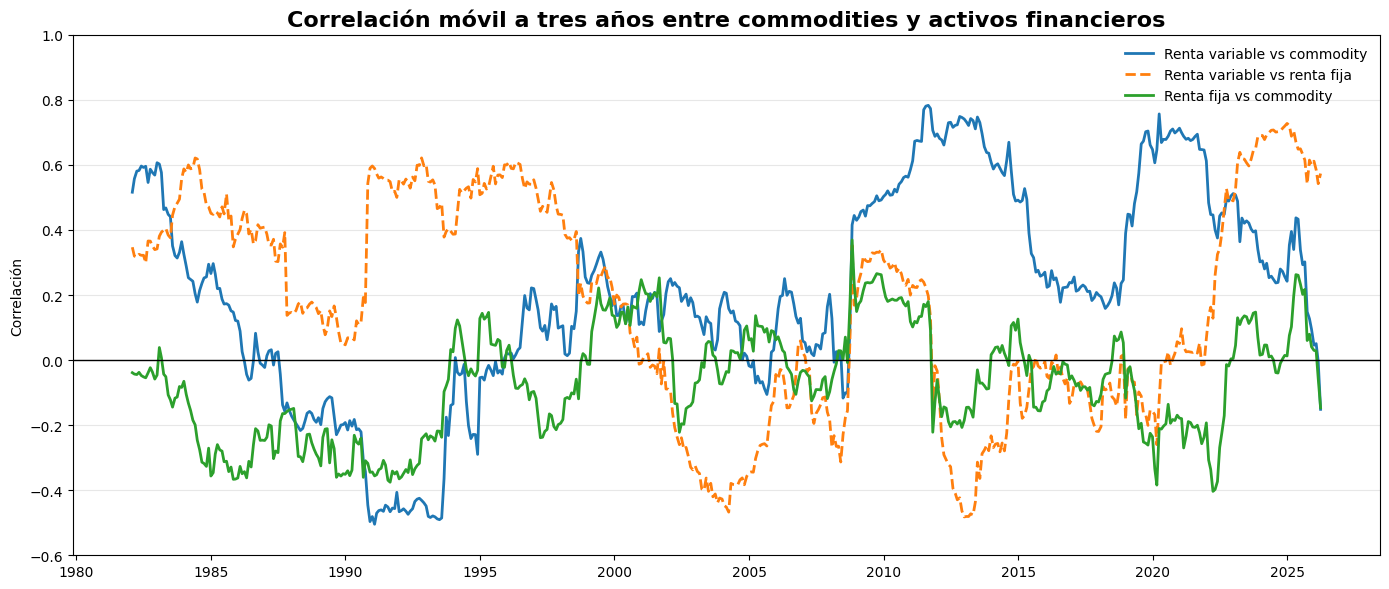

In [ ]:


file_path = "datosLGB.xlsx"
sheets_dict = pd.read_excel(file_path, sheet_name=None)

df = sheets_dict["Grafico"].copy()


df["Date"] = pd.to_datetime(df["Date"])


df = df.sort_values("Date").reset_index(drop=True)


df = df[["Date", "BCOMTR", "RU30INTR", "LBUSTRUU"]]

df["comm_ret"] = df["BCOMTR"].pct_change()
df["equity_ret"] = df["RU30INTR"].pct_change()
df["bond_ret"] = df["LBUSTRUU"].pct_change()



window = 36

df["corr_eq_comm"] = (
    df["equity_ret"]
    .rolling(window)
    .corr(df["comm_ret"])
)

df["corr_eq_bond"] = (
    df["equity_ret"]
    .rolling(window)
    .corr(df["bond_ret"])
)

df["corr_bond_comm"] = (
    df["bond_ret"]
    .rolling(window)
    .corr(df["comm_ret"])
)



df_plot = df.dropna(
    subset=["corr_eq_comm", "corr_eq_bond", "corr_bond_comm"]
).copy()



plt.figure(figsize=(14, 6))

plt.plot(
    df_plot["Date"],
    df_plot["corr_eq_comm"],
    label="Renta variable vs commodity",
    linewidth=2
)


plt.plot(
    df_plot["Date"],
    df_plot["corr_eq_bond"],
    linestyle="--",
    label="Renta variable vs renta fija",
    linewidth=2
)


plt.plot(
    df_plot["Date"],
    df_plot["corr_bond_comm"],
    label="Renta fija vs commodity",
    linewidth=2
)


plt.axhline(
    y=0,
    color="black",
    linewidth=1
)


plt.title(
    "Correlación móvil a tres años entre commodities y activos financieros",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Correlación")
plt.xlabel("")

plt.ylim(-0.6, 1.0)

plt.grid(axis="y", alpha=0.3)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

Regímenes Macro 4

CARGA DE CLI

In [ ]:
cli = sheets_dict["CLI"]
cli['Date'] = pd.to_datetime(cli['Date'])
cli["Date"] = pd.to_datetime(cli["Date"]) + pd.offsets.MonthEnd(0)
cli = cli.set_index('Date')

#cli["delta_CLI"] = cli["CLI"].diff()
cli.sort_index()
cli

,CLI
Date,
2006-12-31,101.582487
2007-01-31,101.703098
2007-02-28,101.821227
2007-03-31,101.943371
2007-04-30,102.059350
...,...
2025-12-31,100.379965
2026-01-31,100.551948
2026-02-28,100.688342


CARGA DE CPI

In [ ]:
cpi = sheets_dict["CPI INDEX"]
cpi["Date"] = pd.to_datetime(cpi["Date"]) + pd.offsets.MonthEnd(0)
cpi = cpi.sort_values("Date")

cpi["CPI"] = cpi["CPI"].astype(str).str.replace(",", ".").astype(float)


cpi["CPI_YoY"] = cpi["CPI"].pct_change(12)


cpi["CPI_3m"] = cpi["CPI_YoY"].rolling(3).mean()
cpi["CPI_36m"] = cpi["CPI_YoY"].rolling(36).mean()


cpi["inflacion_up"] = cpi["CPI_3m"] > cpi["CPI_36m"]


cpi[["CPI_3m","CPI_36m","inflacion_up"]] = cpi[["CPI_3m","CPI_36m","inflacion_up"]].shift(1)
cpi

,Date,CPI,CPI_YoY,CPI_3m,CPI_36m,inflacion_up
433,1990-01-31,127.400,NaN,NaN,NaN,NaN
432,1990-02-28,128.000,NaN,NaN,NaN,False
431,1990-03-31,128.700,NaN,NaN,NaN,False
430,1990-04-30,128.900,NaN,NaN,NaN,False
429,1990-05-31,129.200,NaN,NaN,NaN,False
...,...,...,...,...,...,...
4,2025-11-30,324.122,0.026794,0.028779,0.036268,False
3,2025-12-31,324.054,0.027135,0.028694,0.034860,False
2,2026-01-31,325.252,0.030567,0.028019,0.033639,False
1,2026-02-28,326.785,0.028690,0.028165,0.032695,False


CREACIÓN DE LOS RÉGIMENES

Primero, la inflación se ha aproximado mediante la comparación entre la media móvil de 3 meses y la media móvil de 36 meses de la inflación interanual del CPI, considerando una tendencia inflacionaria alcista cuando la primera superaba a la segunda. La evolución del ciclo económico se hac capturado mediante la variación mensual del CLI. A partir de ambas variables, se  han asignado a uno de los cuatro cuadrantes macroeconómicos definidos por la combinación entre crecimiento o desaceleración económica y aumento o descenso de la inflación. Siguiendo con la metodología propuesta por el artículo. Para evitar fluctuaciones tienen que confirmarse como minimo 3 meses seguidos.

In [ ]:


df = pd.merge(cpi, cli, on="Date", how="left")

df["Date"] = pd.to_datetime(df["Date"]) + pd.offsets.MonthEnd(0)

df = df.sort_values("Date").reset_index(drop=True)

df["delta_CLI"] = df["CLI"].diff()


df = df[
    (df["Date"] >= "2007-01-31") &
    (df["Date"] <= "2026-03-31")
].copy().reset_index(drop=True)



def clasificar(row):

    if pd.isna(row["delta_CLI"]) or pd.isna(row["inflacion_up"]):
        return None

    if row["delta_CLI"] > 0 and row["inflacion_up"]:
        return "Cuadrante I"

    elif row["delta_CLI"] < 0 and row["inflacion_up"]:
        return "Cuadrante II"

    elif row["delta_CLI"] < 0 and not row["inflacion_up"]:
        return "Cuadrante III"

    elif row["delta_CLI"] > 0 and not row["inflacion_up"]:
        return "Cuadrante IV"

    return None

df["Regimen_raw"] = df.apply(clasificar, axis=1)



df["Regimen"] = None

regimen_confirmado = None

for i in range(len(df)):

    if i < 2:
        continue

    actual = df.iloc[i]["Regimen_raw"]
    prev1 = df.iloc[i - 1]["Regimen_raw"]
    prev2 = df.iloc[i - 2]["Regimen_raw"]


    if pd.notna(actual) and actual == prev1 == prev2:
        regimen_confirmado = actual


    df.iloc[i, df.columns.get_loc("Regimen")] = regimen_confirmado


df["Regimen"] = df["Regimen"].bfill()

df

,Date,CPI,CPI_YoY,CPI_3m,CPI_36m,inflacion_up,CLI,delta_CLI,Regimen_raw,Regimen
0,2007-01-31,202.416,0.020756,0.019399,0.031005,False,101.703098,0.120611,Cuadrante IV,Cuadrante IV
1,2007-02-28,203.499,0.024152,0.021967,0.031046,False,101.821227,0.118129,Cuadrante IV,Cuadrante IV
2,2007-03-31,205.352,0.027788,0.023438,0.031247,False,101.943371,0.122144,Cuadrante IV,Cuadrante IV
3,2007-04-30,206.686,0.025737,0.024232,0.031536,False,102.059350,0.115979,Cuadrante IV,Cuadrante IV
4,2007-05-31,207.949,0.026909,0.025892,0.031616,False,102.147407,0.088057,Cuadrante IV,Cuadrante IV
...,...,...,...,...,...,...,...,...,...,...
225,2025-11-30,324.122,0.026794,0.028779,0.036268,False,100.209265,0.262523,Cuadrante IV,Cuadrante IV
226,2025-12-31,324.054,0.027135,0.028694,0.034860,False,100.379965,0.170700,Cuadrante IV,Cuadrante IV
227,2026-01-31,325.252,0.030567,0.028019,0.033639,False,100.551948,0.171983,Cuadrante IV,Cuadrante IV
228,2026-02-28,326.785,0.028690,0.028165,0.032695,False,100.688342,0.136394,Cuadrante IV,Cuadrante IV


VISUALIZACIÓN DE LAS FECHAS POR RÉGIMENES

In [ ]:


df = df.sort_values("Date").copy()

df["grupo"] = (df["Regimen"] != df["Regimen"].shift()).cumsum()


periodos = (
    df.dropna(subset=["Regimen"])
      .groupby(["Regimen", "grupo"])
      .agg(
          inicio=("Date", "min"),
          fin=("Date", "max")
      )
      .reset_index()
)


periodos["inicio"] = periodos["inicio"].dt.strftime("%m-%Y")
periodos["fin"] = periodos["fin"].dt.strftime("%m-%Y")

periodos

,Regimen,grupo,inicio,fin
0,Cuadrante I,6,04-2010,10-2010
1,Cuadrante I,9,12-2011,05-2012
2,Cuadrante I,13,11-2016,06-2018
3,Cuadrante II,3,02-2008,01-2009
4,Cuadrante II,8,05-2011,11-2011
5,Cuadrante II,10,06-2012,10-2012
6,Cuadrante II,14,07-2018,03-2019
7,Cuadrante II,17,04-2020,06-2020
8,Cuadrante II,19,08-2021,07-2023
9,Cuadrante III,2,09-2007,01-2008


GRAFICO MACRO 1

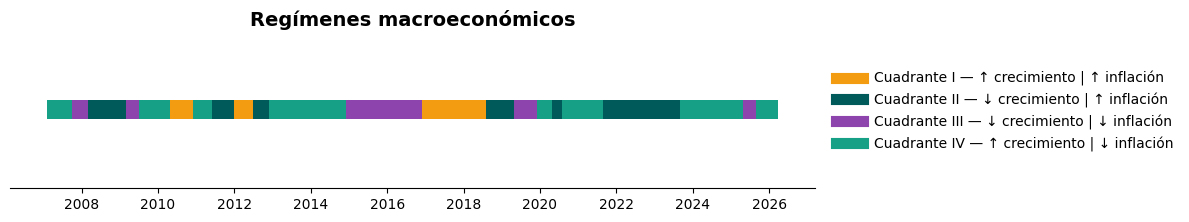

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


colores = {
    "Cuadrante I": "#F39C12",
    "Cuadrante II": "#005a5a",
    "Cuadrante III": "#8E44AD",
    "Cuadrante IV": "#16A085"
}


comentarios = {
    "Cuadrante I": "↑ crecimiento | ↑ inflación",
    "Cuadrante II": "↓ crecimiento | ↑ inflación",
    "Cuadrante III": "↓ crecimiento | ↓ inflación",
    "Cuadrante IV": "↑ crecimiento | ↓ inflación"
}

# Figura
fig, ax = plt.subplots(figsize=(14, 2))

# Dibujar periodos
for i in range(len(df)-1):

    reg = df["Regimen"].iloc[i]

    if pd.isna(reg):
        continue

    inicio = df["Date"].iloc[i]
    fin = df["Date"].iloc[i+1]

    duracion = fin - inicio

    ax.broken_barh(
        [(inicio, duracion)],
        (0.45, 0.12),
        facecolors=colores.get(reg, "gray")
    )

# Estética
ax.set_yticks([])
ax.set_ylim(0, 1)

ax.set_title(
    "Regímenes macroeconómicos",
    fontsize=14,
    fontweight="bold"
)

# Quitar bordes innecesarios
ax.spines[['left', 'right', 'top']].set_visible(False)

# ===== LEYENDA LATERAL =====

handles = []

for reg, color in colores.items():

    texto = f"{reg} — {comentarios[reg]}"

    h = plt.Line2D(
        [0], [0],
        color=color,
        lw=8,
        label=texto
    )

    handles.append(h)

ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=10
)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Espacio extra para la leyenda
plt.subplots_adjust(right=0.7)

plt.show()

GRAFICO MACRO 2

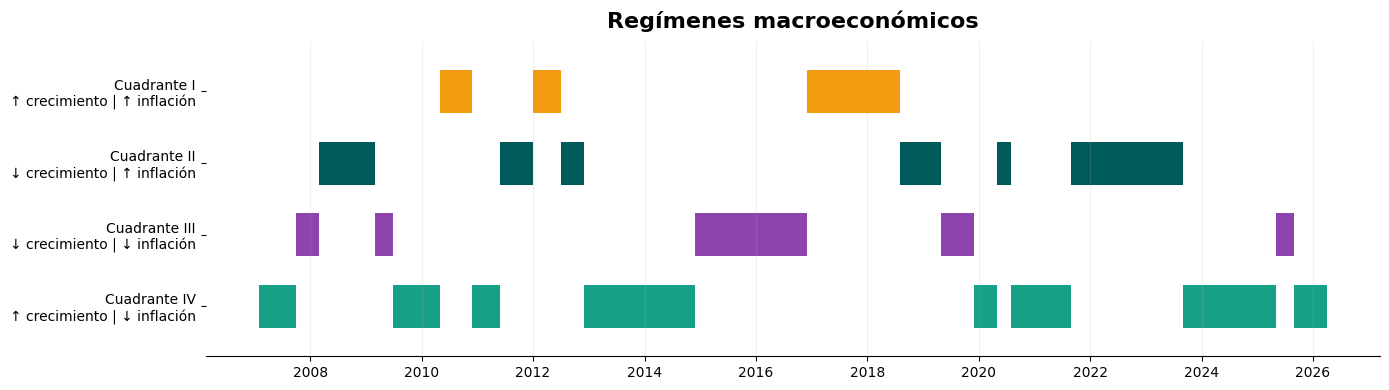

In [ ]:


colores = {
    "Cuadrante I": "#F39C12",
    "Cuadrante II": "#005a5a",
    "Cuadrante III": "#8E44AD",
    "Cuadrante IV": "#16A085"
}



comentarios = {
    "Cuadrante I": "↑ crecimiento | ↑ inflación",
    "Cuadrante II": "↓ crecimiento | ↑ inflación",
    "Cuadrante III": "↓ crecimiento | ↓ inflación",
    "Cuadrante IV": "↑ crecimiento | ↓ inflación"
}



y_pos = {
    "Cuadrante I": 3,
    "Cuadrante II": 2,
    "Cuadrante III": 1,
    "Cuadrante IV": 0
}



fig, ax = plt.subplots(figsize=(14, 4))



for i in range(len(df)-1):

    reg = df["Regimen"].iloc[i]

    if pd.isna(reg):
        continue

    inicio = df["Date"].iloc[i]
    fin = df["Date"].iloc[i+1]

    duracion = fin - inicio

    ax.broken_barh(
        [(inicio, duracion)],
        (y_pos[reg] - 0.3, 0.6),  # (altura inicio, grosor)
        facecolors=colores[reg]
    )


labels = [
    f"{reg}\n{comentarios[reg]}"
    for reg in y_pos.keys()
]

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(labels)



ax.set_title(
    "Regímenes macroeconómicos",
    fontsize=16,
    fontweight="bold",
    pad=10
)


ax.spines[['top', 'right', 'left']].set_visible(False)


ax.grid(axis='x', alpha=0.2)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


ax.set_ylim(-0.7, 3.7)


plt.tight_layout()

plt.show()

Cartera 60/40

Renta variable

In [ ]:
msci_broad_market = sheets_dict["renta variable"]
msci_broad_market['Date'] = pd.to_datetime(msci_broad_market['Date'], dayfirst=True)
msci_broad_market["Date"] = msci_broad_market["Date"] + pd.offsets.MonthEnd(0)
msci_broad_market = msci_broad_market.sort_values("Date")
msci_broad_market

CRSPTM1 = sheets_dict["renta variable post 2013"]
CRSPTM1["Date"] = pd.to_datetime(CRSPTM1['Date'], dayfirst=True)
CRSPTM1["Date"] = CRSPTM1["Date"] + pd.offsets.MonthEnd(0)
CRSPTM1 = CRSPTM1.sort_values("Date")
CRSPTM1

,Date,CRSPTM1
181,2011-03-31,1000.0000
180,2011-04-30,1029.0601
179,2011-05-31,1013.9200
178,2011-06-30,994.3100
177,2011-07-31,971.1900
...,...,...
4,2025-12-31,4868.4858
3,2026-01-31,4942.3018
2,2026-02-28,4911.1509
1,2026-03-31,4661.9541


Renta fija

In [ ]:
LBUSTRUU = sheets_dict["renta fija pre 2009"]
LBUSTRUU['Date'] = pd.to_datetime(LBUSTRUU['Date'], dayfirst=True)
LBUSTRUU["Date"] = LBUSTRUU["Date"] + pd.offsets.MonthEnd(0)
LBUSTRUU = LBUSTRUU.sort_values("Date")
LBUSTRUU

LBUFTRUU = sheets_dict["renta fija"]
LBUFTRUU['Date'] = pd.to_datetime(LBUFTRUU['Date'], dayfirst=True)
LBUFTRUU["Date"] = LBUFTRUU["Date"] + pd.offsets.MonthEnd(0)
LBUFTRUU = LBUFTRUU.sort_values("Date")
LBUFTRUU

,Date,LBUFTRUU
201,2009-07-31,101.64
200,2009-08-31,102.72
199,2009-09-30,103.80
198,2009-10-31,104.33
197,2009-11-30,105.65
...,...,...
4,2025-12-31,159.39
3,2026-01-31,159.53
2,2026-02-28,162.09
1,2026-03-31,159.28


CALCULAR RETURN

In [ ]:
def calcular_returns(df, price_col):
    df = df.copy()
    df["return"] = (df[price_col] / df[price_col].shift(1)) - 1
    return df

In [ ]:
LBUSTRUU = calcular_returns(LBUSTRUU, "LBUSTRUU")
LBUFTRUU = calcular_returns(LBUFTRUU, "LBUFTRUU")
msci_broad_market = calcular_returns(msci_broad_market, "MSCI BROAD MARKET")
CRSPTM1 = calcular_returns(CRSPTM1, "CRSPTM1")

FORMAR LA CARTERA 60/40

In [ ]:
equity = pd.concat([
    msci_broad_market[
        (msci_broad_market["Date"].dt.year < 2013) |
        (
            (msci_broad_market["Date"].dt.year == 2013) &
            (msci_broad_market["Date"].dt.month <= 6)
        )
    ],
    CRSPTM1[
        (CRSPTM1["Date"].dt.year > 2013) |
        (
            (CRSPTM1["Date"].dt.year == 2013) &
            (CRSPTM1["Date"].dt.month > 6)
        )
    ]
]).sort_values("Date")

bonds = pd.concat([
    LBUSTRUU[
        (LBUSTRUU["Date"].dt.year < 2009) |
        (
            (LBUSTRUU["Date"].dt.year == 2009) &
            (LBUSTRUU["Date"].dt.month <= 12)
        )
    ],
    LBUFTRUU[
        (LBUFTRUU["Date"].dt.year > 2009) |
        (
            (LBUFTRUU["Date"].dt.year == 2009) &
            (LBUFTRUU["Date"].dt.month > 12)
        )
    ]
]).sort_values("Date")


portfolio_data = pd.merge(
    equity[["Date", "return"]],
    bonds[["Date", "return"]],
    on="Date",
    suffixes=("_equity", "_bond")
)

portfolio_data["portfolio_60_40"] = (
    0.6 * portfolio_data["return_equity"] +
    0.4 * portfolio_data["return_bond"]
)
portfolio_data

,Date,return_equity,return_bond,portfolio_60_40
0,2006-12-31,NaN,-0.005803,NaN
1,2007-01-31,0.017824,-0.000410,0.010531
2,2007-02-28,-0.018004,0.015420,-0.004635
3,2007-03-31,0.009978,0.000031,0.005999
4,2007-04-30,0.039393,0.005392,0.025793
...,...,...,...,...
228,2025-12-31,-0.001436,-0.001566,-0.001488
229,2026-01-31,0.015162,0.000878,0.009449
230,2026-02-28,-0.006303,0.016047,0.002637
231,2026-03-31,-0.050741,-0.017336,-0.037379


RISK FREE

In [ ]:
Tbill = sheets_dict["rf renta fija"]
Tbill['Date'] = pd.to_datetime(Tbill['Date'], dayfirst=True)
Tbill["Date"] = Tbill["Date"] + pd.offsets.MonthEnd(0)
Tbill = Tbill.sort_values("Date")
Tbill["Rf_monthly"] = (1 + Tbill["Rf_monthly"] / 100) ** (1/12) - 1
Tbill

,Date,Rf_monthly
0,2001-07-31,0.003008
1,2001-08-31,0.002895
2,2001-09-30,0.002206
3,2001-10-31,0.001872
4,2001-11-30,0.001643
...,...,...
293,2025-12-31,0.003089
294,2026-01-31,0.003056
295,2026-02-28,0.003048
296,2026-03-31,0.003064


ALTERNATIVOS

In [ ]:
alternativos = sheets_dict["px_last_"]
alternativos

,Date,UGA,USO,UNG,ICLN,TAN,BCOMENTR
0,2026-04-13,102.055,131.80,10.795,18.98,55.315,110.0716
1,2026-03-31,103.340,127.25,11.730,18.29,55.710,102.1676
2,2026-02-27,72.880,81.95,11.520,18.22,55.000,72.5890
3,2026-01-30,69.370,79.52,16.900,18.15,53.850,77.0174
4,2025-12-31,61.730,69.16,12.260,16.43,49.120,63.8445
...,...,...,...,...,...,...,...
236,2006-08-31,NaN,518.40,NaN,NaN,NaN,594.4890
237,2006-07-31,NaN,556.16,NaN,NaN,NaN,670.6080
238,2006-06-30,NaN,558.16,NaN,NaN,NaN,628.5130
239,2006-05-31,NaN,541.84,NaN,NaN,NaN,629.4280


In [ ]:
alternativos = sheets_dict["px_last_"]
alternativos["Date"] = alternativos["Date"] + pd.offsets.MonthEnd(0)
alternativos = alternativos.sort_values("Date")
alternativos

,Date,UGA,USO,UNG,ICLN,TAN,BCOMENTR
240,2006-04-30,NaN,556.96,NaN,NaN,NaN,645.3050
239,2006-05-31,NaN,541.84,NaN,NaN,NaN,629.4280
238,2006-06-30,NaN,558.16,NaN,NaN,NaN,628.5130
237,2006-07-31,NaN,556.16,NaN,NaN,NaN,670.6080
236,2006-08-31,NaN,518.40,NaN,NaN,NaN,594.4890
...,...,...,...,...,...,...,...
4,2025-12-31,61.730,69.16,12.260,16.43,49.120,63.8445
3,2026-01-31,69.370,79.52,16.900,18.15,53.850,77.0174
2,2026-02-28,72.880,81.95,11.520,18.22,55.000,72.5890
1,2026-03-31,103.340,127.25,11.730,18.29,55.710,102.1676


CALCULAR RETURN

In [ ]:
def calcular_returns_multiple(df, price_cols):
    df = df.copy()

    for col in price_cols:
        df[f"{col}_return"] = (df[col] / df[col].shift(1)) - 1

    return df

In [ ]:
activos = ["UGA", "USO", "UNG", "ICLN", "TAN", "BCOMENTR"]

alternativos_return = calcular_returns_multiple(alternativos, activos)
alternativos_return


,Date,UGA,USO,UNG,ICLN,TAN,BCOMENTR,UGA_return,USO_return,UNG_return,ICLN_return,TAN_return,BCOMENTR_return
240,2006-04-30,NaN,556.96,NaN,NaN,NaN,645.3050,NaN,NaN,NaN,NaN,NaN,NaN
239,2006-05-31,NaN,541.84,NaN,NaN,NaN,629.4280,NaN,-0.027147,NaN,NaN,NaN,-0.024604
238,2006-06-30,NaN,558.16,NaN,NaN,NaN,628.5130,NaN,0.030120,NaN,NaN,NaN,-0.001454
237,2006-07-31,NaN,556.16,NaN,NaN,NaN,670.6080,NaN,-0.003583,NaN,NaN,NaN,0.066976
236,2006-08-31,NaN,518.40,NaN,NaN,NaN,594.4890,NaN,-0.067894,NaN,NaN,NaN,-0.113507
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2025-12-31,61.730,69.16,12.260,16.43,49.120,63.8445,-0.077831,-0.026875,-0.167685,-0.025423,0.004294,-0.090616
3,2026-01-31,69.370,79.52,16.900,18.15,53.850,77.0174,0.123765,0.149798,0.378467,0.104687,0.096295,0.206328
2,2026-02-28,72.880,81.95,11.520,18.22,55.000,72.5890,0.050598,0.030558,-0.318343,0.003857,0.021356,-0.057499
1,2026-03-31,103.340,127.25,11.730,18.29,55.710,102.1676,0.417947,0.552776,0.018229,0.003842,0.012909,0.407480


FORMAMOS LAS CARTERAS CON MÁS DE UN ACTIVO

In [ ]:
alternativos_return["UGA_UNG_USO"] = (
    0.33 * alternativos_return["UNG_return"] +
    0.33 * alternativos_return["UGA_return"]+
    0.33 * alternativos_return["USO_return"]
)
alternativos_return["ICLN_TAN"] = (
    0.5 * alternativos_return["ICLN_return"] +
    0.5 * alternativos_return["TAN_return"]
)
alternativos_return

,Date,UGA,USO,UNG,ICLN,TAN,BCOMENTR,UGA_return,USO_return,UNG_return,ICLN_return,TAN_return,BCOMENTR_return,UGA_UNG_USO,ICLN_TAN
240,2006-04-30,NaN,556.96,NaN,NaN,NaN,645.3050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
239,2006-05-31,NaN,541.84,NaN,NaN,NaN,629.4280,NaN,-0.027147,NaN,NaN,NaN,-0.024604,NaN,NaN
238,2006-06-30,NaN,558.16,NaN,NaN,NaN,628.5130,NaN,0.030120,NaN,NaN,NaN,-0.001454,NaN,NaN
237,2006-07-31,NaN,556.16,NaN,NaN,NaN,670.6080,NaN,-0.003583,NaN,NaN,NaN,0.066976,NaN,NaN
236,2006-08-31,NaN,518.40,NaN,NaN,NaN,594.4890,NaN,-0.067894,NaN,NaN,NaN,-0.113507,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2025-12-31,61.730,69.16,12.260,16.43,49.120,63.8445,-0.077831,-0.026875,-0.167685,-0.025423,0.004294,-0.090616,-0.089889,-0.010565
3,2026-01-31,69.370,79.52,16.900,18.15,53.850,77.0174,0.123765,0.149798,0.378467,0.104687,0.096295,0.206328,0.215170,0.100491
2,2026-02-28,72.880,81.95,11.520,18.22,55.000,72.5890,0.050598,0.030558,-0.318343,0.003857,0.021356,-0.057499,-0.078272,0.012606
1,2026-03-31,103.340,127.25,11.730,18.29,55.710,102.1676,0.417947,0.552776,0.018229,0.003842,0.012909,0.407480,0.326354,0.008376


Unimos los return de todas las posibilidades

In [ ]:

portfolio_data = portfolio_data.merge(
    alternativos_return,
    on="Date",
    how="inner"
)
portfolio_data = portfolio_data[(portfolio_data["Date"] <= "2026-03-31")]
portfolio_data

,Date,return_equity,return_bond,portfolio_60_40,UGA,USO,UNG,ICLN,TAN,BCOMENTR,UGA_return,USO_return,UNG_return,ICLN_return,TAN_return,BCOMENTR_return,UGA_UNG_USO,ICLN_TAN
0,2006-12-31,NaN,-0.005803,NaN,NaN,412.80,NaN,NaN,NaN,436.0620,NaN,-0.054599,NaN,NaN,NaN,-0.134748,NaN,NaN
1,2007-01-31,0.017824,-0.000410,0.010531,NaN,385.92,NaN,NaN,NaN,446.3500,NaN,-0.065116,NaN,NaN,NaN,0.023593,NaN,NaN
2,2007-02-28,-0.018004,0.015420,-0.004635,NaN,409.44,NaN,NaN,NaN,457.4420,NaN,0.060945,NaN,NaN,NaN,0.024850,NaN,NaN
3,2007-03-31,0.009978,0.000031,0.005999,NaN,426.80,NaN,NaN,NaN,483.1050,NaN,0.042399,NaN,NaN,NaN,0.056101,NaN,NaN
4,2007-04-30,0.039393,0.005392,0.025793,NaN,409.92,6657.2798,NaN,NaN,482.5680,NaN,-0.039550,NaN,NaN,NaN,-0.001112,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,2025-11-30,0.001765,0.006177,0.003530,66.94,71.07,14.7300,16.8586,48.91,70.2063,0.020827,-0.020535,0.111698,-0.017919,-0.004275,0.023715,0.036957,-0.011097
228,2025-12-31,-0.001436,-0.001566,-0.001488,61.73,69.16,12.2600,16.4300,49.12,63.8445,-0.077831,-0.026875,-0.167685,-0.025423,0.004294,-0.090616,-0.089889,-0.010565
229,2026-01-31,0.015162,0.000878,0.009449,69.37,79.52,16.9000,18.1500,53.85,77.0174,0.123765,0.149798,0.378467,0.104687,0.096295,0.206328,0.215170,0.100491
230,2026-02-28,-0.006303,0.016047,0.002637,72.88,81.95,11.5200,18.2200,55.00,72.5890,0.050598,0.030558,-0.318343,0.003857,0.021356,-0.057499,-0.078272,0.012606


FORMAMOS LOS PORTFOLIOS

In [ ]:

portfolio_data["portfolio_55_35_UGA_UNG_USO"] = (
    0.55 * portfolio_data["return_equity"] +
    0.35 * portfolio_data["return_bond"] +
    0.10 * portfolio_data["UGA_UNG_USO"]
)
portfolio_data["portfolio_55_35_ICLN_TAN"] = (
    0.55 * portfolio_data["return_equity"] +
    0.35 * portfolio_data["return_bond"] +
    0.10 * portfolio_data["ICLN_TAN"]
)
portfolio_data["portfolio_55_35_BCOMENTR"] = (
    0.55 * portfolio_data["return_equity"] +
    0.35 * portfolio_data["return_bond"] +
    0.10 * portfolio_data["BCOMENTR_return"]
)

portfolio_data["portfolio_60_20_UGA_UNG_USO"] = (
    0.60 * portfolio_data["return_equity"] +
    0.20 * portfolio_data["return_bond"] +
    0.20 * portfolio_data["UGA_UNG_USO"]
)
portfolio_data["portfolio_60_20_ICLN_TAN"] = (
    0.60 * portfolio_data["return_equity"] +
    0.20 * portfolio_data["return_bond"] +
    0.20 * portfolio_data["ICLN_TAN"]
)
portfolio_data["portfolio_60_20_BCOMENTR"] = (
    0.60 * portfolio_data["return_equity"] +
    0.20 * portfolio_data["return_bond"] +
    0.20 * portfolio_data["BCOMENTR_return"]
)
portfolio_data["portfolio_50_30_UGA_UNG_USO"] = (
    0.50 * portfolio_data["return_equity"] +
    0.30 * portfolio_data["return_bond"] +
    0.20 * portfolio_data["UGA_UNG_USO"]
)
portfolio_data["portfolio_50_30_ICLN_TAN"] = (
    0.50 * portfolio_data["return_equity"] +
    0.30 * portfolio_data["return_bond"] +
    0.20 * portfolio_data["ICLN_TAN"]
)
portfolio_data["portfolio_50_30_BCOMENTR"] = (
    0.50 * portfolio_data["return_equity"] +
    0.30 * portfolio_data["return_bond"] +
    0.20 * portfolio_data["BCOMENTR_return"]
)

In [ ]:
df_total = portfolio_data.merge(
    df[["Date", "Regimen"]],
    on="Date",
    how="inner"
)

df_total = df_total.merge(
    Tbill[["Date", "Rf_monthly"]],
    on="Date",
    how="inner"
)

df_total

,Date,return_equity,return_bond,portfolio_60_40,UGA,USO,UNG,ICLN,TAN,BCOMENTR,...,portfolio_55_35_ICLN_TAN,portfolio_55_35_BCOMENTR,portfolio_60_20_UGA_UNG_USO,portfolio_60_20_ICLN_TAN,portfolio_60_20_BCOMENTR,portfolio_50_30_UGA_UNG_USO,portfolio_50_30_ICLN_TAN,portfolio_50_30_BCOMENTR,Regimen,Rf_monthly
0,2007-01-31,0.017824,-0.000410,0.010531,NaN,385.92,NaN,NaN,NaN,446.3500,...,NaN,0.012019,NaN,NaN,0.015331,NaN,NaN,0.013508,Cuadrante IV,0.004026
1,2007-02-28,-0.018004,0.015420,-0.004635,NaN,409.44,NaN,NaN,NaN,457.4420,...,NaN,-0.002020,NaN,NaN,-0.002749,NaN,NaN,0.000594,Cuadrante IV,0.004217
2,2007-03-31,0.009978,0.000031,0.005999,NaN,426.80,NaN,NaN,NaN,483.1050,...,NaN,0.011108,NaN,NaN,0.017213,NaN,NaN,0.016218,Cuadrante IV,0.004241
3,2007-04-30,0.039393,0.005392,0.025793,NaN,409.92,6657.2798,NaN,NaN,482.5680,...,NaN,0.023443,NaN,NaN,0.024492,NaN,NaN,0.021092,Cuadrante IV,0.004066
4,2007-05-31,0.034788,-0.007579,0.017841,NaN,391.68,6622.7202,NaN,NaN,473.5220,...,NaN,0.014606,NaN,NaN,0.015608,NaN,NaN,0.011371,Cuadrante IV,0.003931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,2025-11-30,0.001765,0.006177,0.003530,66.94,71.07,14.7300,16.8586,48.91,70.2063,...,0.002023,0.005504,0.009686,0.000075,0.007038,0.010127,0.000516,0.007479,Cuadrante IV,0.003298
226,2025-12-31,-0.001436,-0.001566,-0.001488,61.73,69.16,12.2600,16.4300,49.12,63.8445,...,-0.002394,-0.010400,-0.019153,-0.003288,-0.019298,-0.019166,-0.003301,-0.019311,Cuadrante IV,0.003089
227,2026-01-31,0.015162,0.000878,0.009449,69.37,79.52,16.9000,18.1500,53.85,77.0174,...,0.018696,0.029279,0.052307,0.029371,0.050538,0.050878,0.027943,0.049110,Cuadrante IV,0.003056
228,2026-02-28,-0.006303,0.016047,0.002637,72.88,81.95,11.5200,18.2200,55.00,72.5890,...,0.003411,-0.003600,-0.016227,0.001949,-0.012072,-0.013992,0.004184,-0.009837,Cuadrante IV,0.003048


GRAFICO DE LA EVOLUCIÓN DE LAS CARTERAS

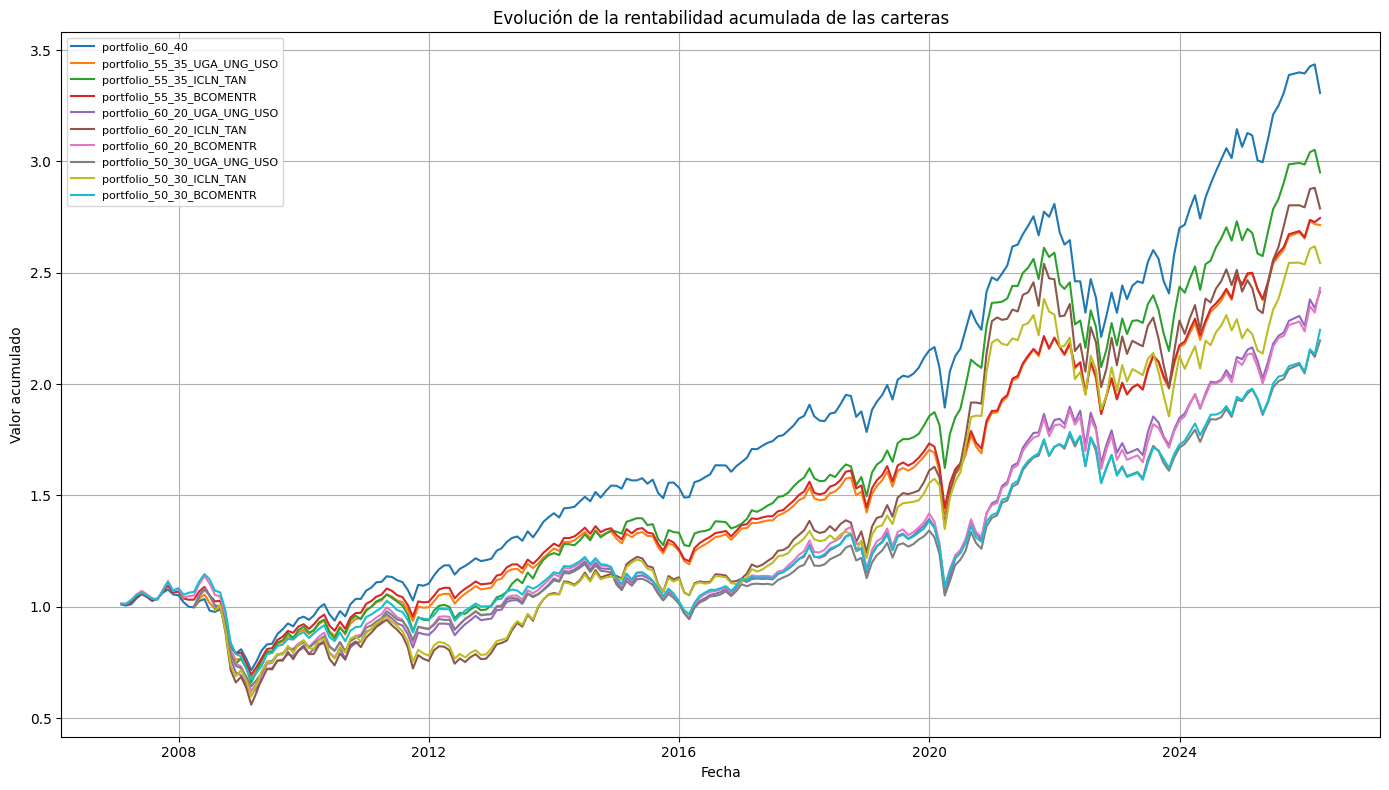

In [ ]:


df_total['Date'] = pd.to_datetime(df_total['Date'])

portfolios = [
    'portfolio_60_40',
    'portfolio_55_35_UGA_UNG_USO',
    'portfolio_55_35_ICLN_TAN',
    'portfolio_55_35_BCOMENTR',
    'portfolio_60_20_UGA_UNG_USO',
    'portfolio_60_20_ICLN_TAN',
    'portfolio_60_20_BCOMENTR',
    'portfolio_50_30_UGA_UNG_USO',
    'portfolio_50_30_ICLN_TAN',
    'portfolio_50_30_BCOMENTR'
]


cum_returns = (1 + df_total[portfolios]).cumprod()

plt.figure(figsize=(14, 8))

for portfolio in portfolios:
    plt.plot(df_total['Date'], cum_returns[portfolio], label=portfolio)

plt.title('Evolución de la rentabilidad acumulada de las carteras')
plt.xlabel('Fecha')
plt.ylabel('Valor acumulado')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

plt.show()

COMPARACIÓN DE LOS ACTIVOS

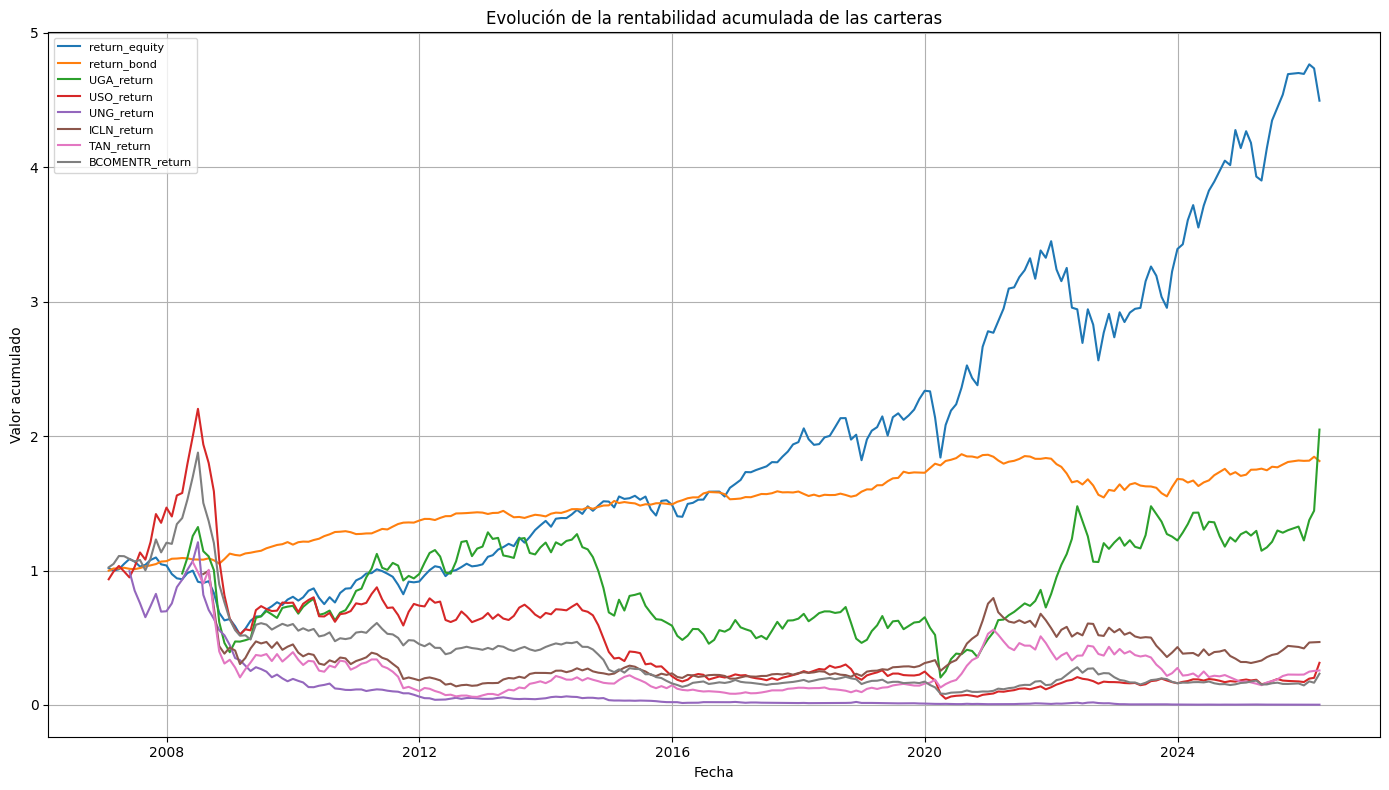

In [ ]:

df_total['Date'] = pd.to_datetime(df_total['Date'])

portfolios = [
    'return_equity',
    'return_bond',
    'UGA_return',
    'USO_return',
    'UNG_return',
    'ICLN_return',
    'TAN_return',
    'BCOMENTR_return'
]


cum_returns = (1 + df_total[portfolios]).cumprod()

plt.figure(figsize=(14, 8))

for portfolio in portfolios:
    plt.plot(df_total['Date'], cum_returns[portfolio], label=portfolio)

plt.title('Evolución de la rentabilidad acumulada de las carteras')
plt.xlabel('Fecha')
plt.ylabel('Valor acumulado')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

plt.show()

GRAFICO DE LA RENTABILIDAD MEDIA ANUALIZADA POR RÉGIMENES

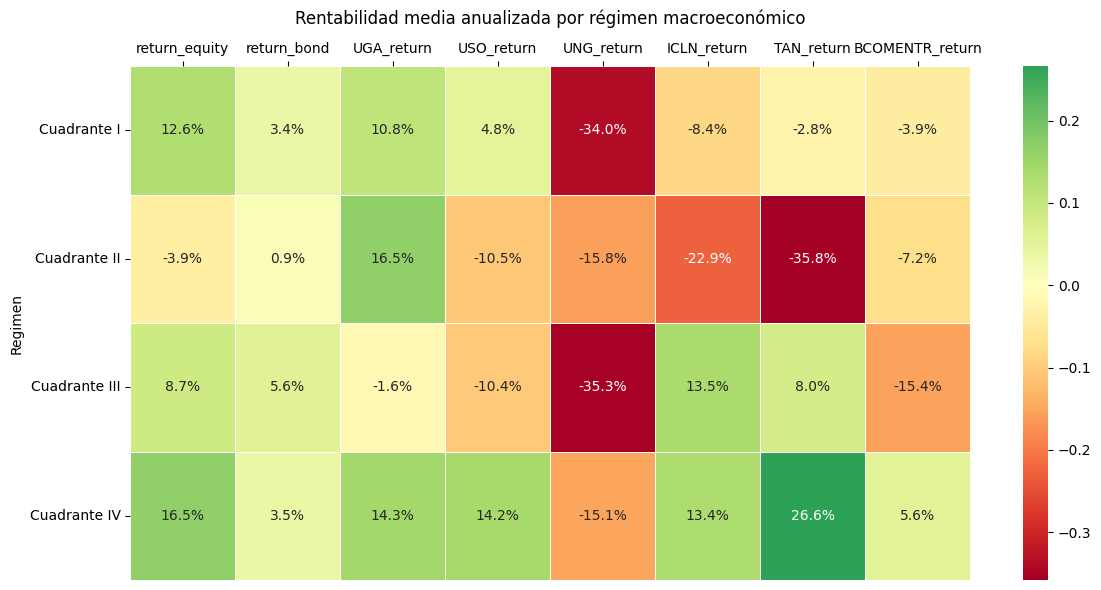

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

products = [
    'return_equity',
    'return_bond',
    'UGA_return',
    'USO_return',
    'UNG_return',
    'ICLN_return',
    'TAN_return',
    'BCOMENTR_return'
]


heatmap_data = df_total.groupby('Regimen')[products].mean() * 12

plt.figure(figsize=(12, 6))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')


plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.title('Rentabilidad media anualizada por régimen macroeconómico', pad=30)

plt.tight_layout()
plt.show()

CÁLCULOS

RENTABILIDAD GLOBAL

In [ ]:

portfolio_cols = [
    col for col in df_total.columns
    if col.startswith("portfolio")
]

resultados_global = []

for col in portfolio_cols:

    sub = df_total.dropna(subset=[col, "Rf_monthly"])

    if len(sub) == 0:
        continue

    excess = sub[col] - sub["Rf_monthly"]


    sharpe = (excess.mean() / excess.std()) * np.sqrt(12)


    vol = sub[col].std() * np.sqrt(12)
    ret = sub[col].mean() * 12


    downside_diff = np.minimum(excess, 0)

    downside_std = np.sqrt(np.mean(downside_diff**2)) * np.sqrt(12)

    if downside_std > 0:
        sortino = (excess.mean() * 12) / downside_std
    else:
        sortino = None


    cumulative = (1 + sub[col]).cumprod()

    rolling_max = cumulative.cummax()

    drawdown = (cumulative - rolling_max) / rolling_max

    max_drawdown = drawdown.min()

    resultados_global.append({
        "Portfolio": col,
        "Sharpe_Global": sharpe,
        "Sortino_Global": sortino,
        "Volatilidad_Global": vol,
        "Return_Global": ret,
        "Maximum_Drawdown": max_drawdown,
        "Observaciones": len(sub)
    })

df_global = pd.DataFrame(resultados_global).sort_values(
    by="Sharpe_Global",
    ascending=False
)

df_global

,Portfolio,Sharpe_Global,Sortino_Global,Volatilidad_Global,Return_Global,Maximum_Drawdown,Observaciones
0,portfolio_60_40,0.525037,0.762055,0.101073,0.067698,-0.336579,230
2,portfolio_55_35_ICLN_TAN,0.459057,0.660485,0.122008,0.068911,-0.344509,212
1,portfolio_55_35_UGA_UNG_USO,0.451093,0.629417,0.107594,0.061462,-0.357180,216
3,portfolio_55_35_BCOMENTR,0.416871,0.578805,0.105051,0.058399,-0.365484,230
5,portfolio_60_20_ICLN_TAN,0.365950,0.521722,0.158529,0.070923,-0.443402,212
8,portfolio_50_30_ICLN_TAN,0.349266,0.497766,0.145128,0.063602,-0.407651,212
4,portfolio_60_20_UGA_UNG_USO,0.339923,0.461493,0.132849,0.058090,-0.443389,216
7,portfolio_50_30_UGA_UNG_USO,0.319737,0.431427,0.119031,0.050993,-0.403234,216
6,portfolio_60_20_BCOMENTR,0.311729,0.420897,0.129736,0.055041,-0.453063,230
9,portfolio_50_30_BCOMENTR,0.297087,0.398887,0.116140,0.049100,-0.413576,230


CORRELACION CARTERAS

In [ ]:
activos = ["UGA", "USO", "UNG", "ICLN", "TAN", "BCOMENTR"]

data_all = alternativos_return.merge(
    df_total[["Date", "portfolio_60_40"]],
    on="Date",
    how="inner"
)

cols = [f"{a}_return" for a in activos] + ["portfolio_60_40"]

corr_energy_vs_6040 = data_all[cols].corr()


corr_energy_vs_6040["portfolio_60_40"]
corr_energy_vs_6040

,UGA_return,USO_return,UNG_return,ICLN_return,TAN_return,BCOMENTR_return,portfolio_60_40
UGA_return,1.000000,0.790110,0.090321,0.352774,0.327633,0.744305,0.386148
USO_return,0.790110,1.000000,0.164641,0.297961,0.283743,0.839147,0.294987
UNG_return,0.090321,0.164641,1.000000,0.103126,0.093268,0.609991,0.063198
ICLN_return,0.352774,0.297961,0.103126,1.000000,0.922278,0.297058,0.711297
TAN_return,0.327633,0.283743,0.093268,0.922278,1.000000,0.281076,0.654650
BCOMENTR_return,0.744305,0.839147,0.609991,0.297058,0.281076,1.000000,0.294394
portfolio_60_40,0.386148,0.294987,0.063198,0.711297,0.654650,0.294394,1.000000


POR RÉGIMEN

cuadrante 1

In [ ]:


portfolio_cols = [
    col for col in df_total.columns
    if col.startswith("portfolio")
]

resultados_q1 = []

df_q1 = df_total[df_total["Regimen"] == "Cuadrante I"]

for col in portfolio_cols:

    sub = df_q1.dropna(subset=[col, "Rf_monthly"])

    if len(sub) == 0:
        continue

    excess = sub[col] - sub["Rf_monthly"]

    sharpe = (
        excess.mean() / excess.std()
    ) * np.sqrt(12)


    vol = sub[col].std() * np.sqrt(12)


    ret = sub[col].mean() * 12


    downside_diff = np.minimum(excess, 0)

    downside_std = (
        np.sqrt(np.mean(downside_diff ** 2))
    ) * np.sqrt(12)

    if downside_std > 0:
        sortino = (
            excess.mean() * 12
        ) / downside_std
    else:
        sortino = None

    resultados_q1.append({
        "Portfolio": col,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Volatilidad": vol,
        "Return": ret,
        "Observaciones": len(sub)
    })

df_q1_resultados = pd.DataFrame(resultados_q1).sort_values(
    by="Sharpe",
    ascending=False
)

df_q1_resultados = df_q1_resultados.copy()

columnas_numericas = [
    "Sharpe",
    "Sortino",
    "Volatilidad",
    "Return"
]

for col in columnas_numericas:
    df_q1_resultados[col] = (
        df_q1_resultados[col]
        .map(lambda x: f"{x:.4f}".replace(".", ","))
    )

df_q1_resultados

,Portfolio,Sharpe,Sortino,Volatilidad,Return,Observaciones
0,portfolio_60_40,"1,1048","1,8211","0,0749","0,0895",33
3,portfolio_55_35_BCOMENTR,"0,8874","1,3548","0,0801","0,0775",33
1,portfolio_55_35_UGA_UNG_USO,"0,8641","1,3290","0,0796","0,0753",33
2,portfolio_55_35_ICLN_TAN,"0,7637","1,2051","0,0907","0,0758",33
6,portfolio_60_20_BCOMENTR,"0,6771","0,9855","0,1010","0,0748",33
9,portfolio_50_30_BCOMENTR,"0,6729","0,9771","0,0880","0,0656",33
4,portfolio_60_20_UGA_UNG_USO,"0,6368","0,9366","0,1004","0,0704",33
7,portfolio_50_30_UGA_UNG_USO,"0,6256","0,9191","0,0876","0,0612",33
5,portfolio_60_20_ICLN_TAN,"0,5329","0,8073","0,1218","0,0714",33
8,portfolio_50_30_ICLN_TAN,"0,5085","0,7781","0,1095","0,0622",33


CUADRANTE 2

In [ ]:
import numpy as np
import pandas as pd

portfolio_cols = [
    col for col in df_total.columns
    if col.startswith("portfolio")
]

resultados_q1 = []

df_q1 = df_total[df_total["Regimen"] == "Cuadrante II"]

for col in portfolio_cols:

    sub = df_q1.dropna(subset=[col, "Rf_monthly"])

    if len(sub) == 0:
        continue

    excess = sub[col] - sub["Rf_monthly"]


    sharpe = (
        excess.mean() / excess.std()
    ) * np.sqrt(12)


    vol = sub[col].std() * np.sqrt(12)


    ret = sub[col].mean() * 12


    downside_diff = np.minimum(excess, 0)

    downside_std = (
        np.sqrt(np.mean(downside_diff ** 2))
    ) * np.sqrt(12)

    if downside_std > 0:
        sortino = (
            excess.mean() * 12
        ) / downside_std
    else:
        sortino = None

    resultados_q1.append({
        "Portfolio": col,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Volatilidad": vol,
        "Return": ret,
        "Observaciones": len(sub)
    })

df_q1_resultados = pd.DataFrame(resultados_q1).sort_values(
    by="Sharpe",
    ascending=False
)

df_q1_resultados = df_q1_resultados.copy()

columnas_numericas = [
    "Sharpe",
    "Sortino",
    "Volatilidad",
    "Return"
]

for col in columnas_numericas:
    df_q1_resultados[col] = (
        df_q1_resultados[col]
        .map(lambda x: f"{x:.4f}".replace(".", ","))
    )

display(df_q1_resultados)

,Portfolio,Sharpe,Sortino,Volatilidad,Return,Observaciones
1,portfolio_55_35_UGA_UNG_USO,"-0,2429","-0,3069","0,1417","-0,0200",59
4,portfolio_60_20_UGA_UNG_USO,"-0,2467","-0,3095","0,1724","-0,0281",59
7,portfolio_50_30_UGA_UNG_USO,"-0,2480","-0,3094","0,1547","-0,0240",59
0,portfolio_60_40,"-0,2527","-0,3243","0,1349","-0,0195",60
3,portfolio_55_35_BCOMENTR,"-0,2830","-0,3549","0,1406","-0,0252",60
6,portfolio_60_20_BCOMENTR,"-0,2934","-0,3633","0,1712","-0,0357",60
9,portfolio_50_30_BCOMENTR,"-0,2956","-0,3636","0,1538","-0,0309",60
2,portfolio_55_35_ICLN_TAN,"-0,3521","-0,4424","0,1620","-0,0425",55
5,portfolio_60_20_ICLN_TAN,"-0,4359","-0,5382","0,2069","-0,0756",55
8,portfolio_50_30_ICLN_TAN,"-0,4545","-0,5597","0,1894","-0,0715",55


Cuadrante 3

In [ ]:
import numpy as np
import pandas as pd

portfolio_cols = [
    col for col in df_total.columns
    if col.startswith("portfolio")
]

resultados_q1 = []

df_q1 = df_total[df_total["Regimen"] == "Cuadrante III"]

for col in portfolio_cols:

    sub = df_q1.dropna(subset=[col, "Rf_monthly"])

    if len(sub) == 0:
        continue

    excess = sub[col] - sub["Rf_monthly"]


    sharpe = (
        excess.mean() / excess.std()
    ) * np.sqrt(12)


    vol = sub[col].std() * np.sqrt(12)


    ret = sub[col].mean() * 12


    downside_diff = np.minimum(excess, 0)

    downside_std = (
        np.sqrt(np.mean(downside_diff ** 2))
    ) * np.sqrt(12)

    if downside_std > 0:
        sortino = (
            excess.mean() * 12
        ) / downside_std
    else:
        sortino = None

    resultados_q1.append({
        "Portfolio": col,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Volatilidad": vol,
        "Return": ret,
        "Observaciones": len(sub)
    })

df_q1_resultados = pd.DataFrame(resultados_q1).sort_values(
    by="Sharpe",
    ascending=False
)

df_q1_resultados = df_q1_resultados.copy()

columnas_numericas = [
    "Sharpe",
    "Sortino",
    "Volatilidad",
    "Return"
]

for col in columnas_numericas:
    df_q1_resultados[col] = (
        df_q1_resultados[col]
        .map(lambda x: f"{x:.4f}".replace(".", ","))
    )

display(df_q1_resultados)

,Portfolio,Sharpe,Sortino,Volatilidad,Return,Observaciones
2,portfolio_55_35_ICLN_TAN,"0,7479","1,2664","0,1119","0,0923",39
0,portfolio_60_40,"0,6967","1,1692","0,0909","0,0750",44
8,portfolio_50_30_ICLN_TAN,"0,6425","1,0647","0,1341","0,0948",39
5,portfolio_60_20_ICLN_TAN,"0,6290","1,0396","0,1483","0,1019",39
1,portfolio_55_35_UGA_UNG_USO,"0,5133","0,8255","0,0983","0,0593",39
3,portfolio_55_35_BCOMENTR,"0,4145","0,6508","0,0983","0,0524",44
4,portfolio_60_20_UGA_UNG_USO,"0,2155","0,3216","0,1251","0,0359",39
7,portfolio_50_30_UGA_UNG_USO,"0,1775","0,2642","0,1116","0,0288",39
6,portfolio_60_20_BCOMENTR,"0,1667","0,2462","0,1266","0,0328",44
9,portfolio_50_30_BCOMENTR,"0,1593","0,2364","0,1131","0,0297",44


cuadrante 4

In [ ]:
import numpy as np
import pandas as pd

portfolio_cols = [
    col for col in df_total.columns
    if col.startswith("portfolio")
]

resultados_q1 = []

df_q1 = df_total[df_total["Regimen"] == "Cuadrante IV"]

for col in portfolio_cols:

    sub = df_q1.dropna(subset=[col, "Rf_monthly"])

    if len(sub) == 0:
        continue

    excess = sub[col] - sub["Rf_monthly"]


    sharpe = (
        excess.mean() / excess.std()
    ) * np.sqrt(12)


    vol = sub[col].std() * np.sqrt(12)


    ret = sub[col].mean() * 12


    downside_diff = np.minimum(excess, 0)

    downside_std = (
        np.sqrt(np.mean(downside_diff ** 2))
    ) * np.sqrt(12)

    if downside_std > 0:
        sortino = (
            excess.mean() * 12
        ) / downside_std
    else:
        sortino = None

    resultados_q1.append({
        "Portfolio": col,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Volatilidad": vol,
        "Return": ret,
        "Observaciones": len(sub)
    })

df_q1_resultados = pd.DataFrame(resultados_q1).sort_values(
    by="Sharpe",
    ascending=False
)

df_q1_resultados = df_q1_resultados.copy()

columnas_numericas = [
    "Sharpe",
    "Sortino",
    "Volatilidad",
    "Return"
]

for col in columnas_numericas:
    df_q1_resultados[col] = (
        df_q1_resultados[col]
        .map(lambda x: f"{x:.4f}".replace(".", ","))
    )

display(df_q1_resultados)

,Portfolio,Sharpe,Sortino,Volatilidad,Return,Observaciones
0,portfolio_60_40,"1,0838","1,7675","0,0857","0,1128",93
2,portfolio_55_35_ICLN_TAN,"1,0644","1,7587","0,1036","0,1276",85
1,portfolio_55_35_UGA_UNG_USO,"1,0559","1,5987","0,0914","0,1136",85
3,portfolio_55_35_BCOMENTR,"1,0267","1,5600","0,0863","0,1084",93
5,portfolio_60_20_ICLN_TAN,"0,9909","1,6571","0,1351","0,1513",85
8,portfolio_50_30_ICLN_TAN,"0,9579","1,5984","0,1251","0,1372",85
4,portfolio_60_20_UGA_UNG_USO,"0,9364","1,3523","0,1136","0,1233",85
6,portfolio_60_20_BCOMENTR,"0,9189","1,3384","0,1060","0,1171",93
7,portfolio_50_30_UGA_UNG_USO,"0,8996","1,2874","0,1027","0,1093",85
9,portfolio_50_30_BCOMENTR,"0,8851","1,2795","0,0954","0,1040",93


GRAFICOS

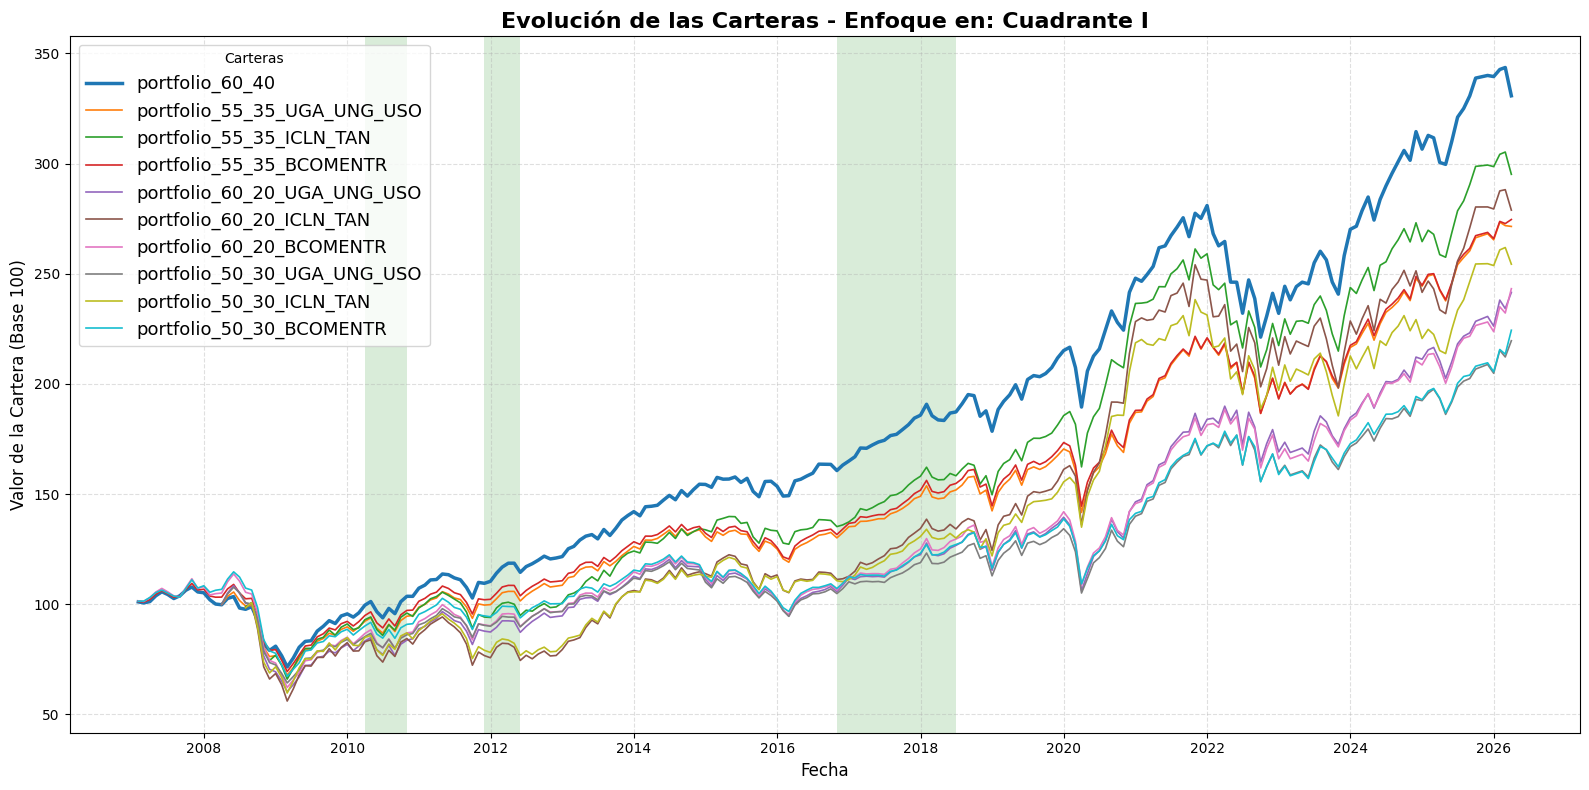

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df_plot = df_total.copy()
for col in portfolio_cols:
    df_plot[col] = (1 + df_plot[col]).cumprod() * 100


colores_regimen = {
    "Cuadrante I": "green",     # Expansión
    "Cuadrante II": "red",      # Estanflación
    "Cuadrante III": "orange",  # Desaceleración
    "Cuadrante IV": "blue"      # Ricitos de oro
}


regimenes_a_mostrar = ["Cuadrante I"]


fig, ax = plt.subplots(figsize=(16, 8))


for col in portfolio_cols:
    lw = 2.5 if col == "portfolio_60_40" else 1.2
    ax.plot(df_plot["Date"], df_plot[col], label=col, linewidth=lw)


for i in range(1, len(df_plot)):
    fecha_inicio = df_plot.iloc[i-1]["Date"]
    fecha_fin = df_plot.iloc[i]["Date"]
    regimen = df_plot.iloc[i]["Regimen"]


    if pd.notna(regimen) and regimen in colores_regimen and regimen in regimenes_a_mostrar:
        ax.axvspan(
            fecha_inicio,
            fecha_fin,
            color=colores_regimen[regimen],
            alpha=0.15, # Efecto acuoso
            lw=0
        )


titulos_filtro = ", ".join(regimenes_a_mostrar)
ax.set_title(f"Evolución de las Carteras - Enfoque en: {titulos_filtro}", fontsize=16, fontweight='bold')
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Valor de la Cartera (Base 100)", fontsize=12)


ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


ax.legend(loc='best', title="Carteras", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()